# Processamento de Imagens de Satélite: Índices Espectrais e Detecção de Mudanças

Nesta aula vamos colocar em prática o que aprendemos sobre STAC para investigar um evento real. **O rompimento da barragem de rejeitos da Vale em Brumadinho (MG)**, ocorrido em 25 de janeiro de 2019.

Nosso fluxo de trabalho será:
- Buscar imagens CBERS-4/MUX de **antes** e **depois** do rompimento;
- Calcular índices espectrais (**NDVI**, **NDWI** e **EVI**);
- Analisar o histograma desses índices;
- Classificar a imagem por limiares (thresholding);
- Calcular a **diferença entre as duas datas** para visualizar o impacto do desastre.



Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/fundamentals_gis_rs/week2/RS-Image_Processing.ipynb)

In [ ]:
# rode isso apenas se voce estiver no colab! 
# git clone https://github.com/ftl-brazil-2026/ebook.git
# pip install -r requirements.txt

In [1]:
from pystac_client import Client
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import psutil

In [2]:
def check_memory(label: str = "", warn_threshold: float = 85.0) -> None:
    """Imprime o uso atual de RAM e alerta se estiver perto do limite da máquina."""
    mem = psutil.virtual_memory()
    used_gb = mem.used / (1024 ** 3)
    total_gb = mem.total / (1024 ** 3)
    available_gb = mem.available / (1024 ** 3)

    prefix = f"[RAM] {label}: " if label else "[RAM] "
    print(f"{prefix}{used_gb:.2f} GB usados de {total_gb:.2f} GB ({mem.percent:.1f}%) | disponível: {available_gb:.2f} GB")

    if mem.percent >= warn_threshold:
        print(f"ATENÇÃO: uso de RAM acima de {warn_threshold:.0f}%! Considere reiniciar o kernel "
              "ou reduzir a área de interesse (bbox/window).")

check_memory()

[RAM] 15.60 GB usados de 32.00 GB (58.2%) | disponível: 13.39 GB


## Buscando as imagens no STAC

Na aula passada utilizamos os dados do CBERS4, nessa aula vamos utilizar os dados de sentinel-2 para ter acesso as bandas SWIR.
Vamos buscar cenas sobre a região da barragem, tanto **antes** quanto **depois** de 25/01/2019.

Área de interesse: entorno da mina Córrego do Feijão / Brumadinho-MG.

Caso voce queira cobrir uma outra área de interesse, pode usar esse link aqui para definir a bbox facilmente:
[bbox finder](https://rodostoteknoloji.com/online-tools/bbox-tool-en.html)

Para baixar as imagens do Sentinel-2, é preciso gerar as API keys. Siga esse link aqui para mais informações: [API - CDSE](https://documentation.dataspace.copernicus.eu/APIs/S3.html).

Se você já tem uma conta, só precisa acessar esse link: [CDSE-API-KEYS-GENERATION](https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials), depois gerar uma nova chave API, cole tanto a sua Acess Key como Secret Key dentro do .env, como indicado em nosso .env_copy.

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
#os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_ACCESS_KEY_ID"] = os.environ.get("CDSE_CLIENT")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ.get("CDSE_SECRET")
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"

# endpoint da AWS pro ecossistema copernicus no STAC
cdse_stac = "https://stac.dataspace.copernicus.eu/v1/"
client = Client.open(cdse_stac)

In [ ]:
list(client.get_all_collections())

In [6]:
# bbox aproximado cobrindo a barragem de Brumadinho / Córrego do Feijão
# lembrando que nosso bbox ta em WGS84 - EPSG4326 (classico de qualquer análise, mas não é um sistema projetado! )
bbox = [-44.142273, -20.144694, -44.103469, -20.110041]

In [7]:
import folium
from shapely.geometry import box

bounds_polygon = box(*bbox)

centro_lat = (bbox[1] + bbox[3]) / 2
centro_lon = (bbox[0] + bbox[2]) / 2

m = folium.Map(location=[centro_lat, centro_lon], zoom_start=15)


folium.GeoJson(
    bounds_polygon.__geo_interface__,
    name="Bounds",
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'blue',
        'weight': 3,
        'fillOpacity': 0
    }
).add_to(m)

m

In [19]:
search_antes = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2018-10-01/2019-01-24",
    query={"eo:cloud_cover": {"lt": 15}}
)

search_depois = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2019-01-26/2019-04-30",
    query={"eo:cloud_cover": {"lt": 15}}
)

print("Imagens antes do rompimento:", search_antes.matched())
for item in search_antes.items():
    print(" ", item.id, "- nuvens:", round(item.properties["eo:cloud_cover"], 1), "%")

print("\nImagens depois do rompimento:", search_depois.matched())
for item in search_depois.items():
    print(" ", item.id, "- nuvens:", round(item.properties["eo:cloud_cover"], 1), "%")

Imagens antes do rompimento: None
  S2A_MSIL2A_20190122T131241_N0500_R138_T23KNT_20221210T105448 - nuvens: 2.2 %
  S2B_MSIL2A_20190117T131239_N0500_R138_T23KNT_20221220T235155 - nuvens: 3.4 %
  S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510 - nuvens: 0.8 %

Imagens depois do rompimento: None
  S2B_MSIL2A_20190427T131249_N0500_R138_T23KNT_20221021T034403 - nuvens: 2.9 %
  S2B_MSIL2A_20190308T131239_N0500_R138_T23KNT_20221114T091205 - nuvens: 5.1 %
  S2A_MSIL2A_20190201T131241_N0500_R138_T23KNT_20221206T064832 - nuvens: 1.0 %


Vamos escolher duas cenas da **mesma órbita/tile** (mesmo enquadramento), uma de cada período, com baixa cobertura de nuvens.

In [20]:
item_antes = list(list(search_antes.items()))[2]

item_depois = list(list(search_depois.items()))[1]

print(item_antes)
print(item_depois)

<Item id=S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510>
<Item id=S2B_MSIL2A_20190308T131239_N0500_R138_T23KNT_20221114T091205>


In [21]:
item_antes.assets

{'AOT_10m': <Asset href=s3://eodata/Sentinel-2/MSI/L2A_N0500/2019/01/07/S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510.SAFE/GRANULE/L2A_T23KNT_A009602_20190107T131241/IMG_DATA/R10m/T23KNT_20190107T131239_AOT_10m.jp2>,
 'AOT_20m': <Asset href=s3://eodata/Sentinel-2/MSI/L2A_N0500/2019/01/07/S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510.SAFE/GRANULE/L2A_T23KNT_A009602_20190107T131241/IMG_DATA/R20m/T23KNT_20190107T131239_AOT_20m.jp2>,
 'AOT_60m': <Asset href=s3://eodata/Sentinel-2/MSI/L2A_N0500/2019/01/07/S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510.SAFE/GRANULE/L2A_T23KNT_A009602_20190107T131241/IMG_DATA/R60m/T23KNT_20190107T131239_AOT_60m.jp2>,
 'B01_20m': <Asset href=s3://eodata/Sentinel-2/MSI/L2A_N0500/2019/01/07/S2B_MSIL2A_20190107T131239_N0500_R138_T23KNT_20221216T195510.SAFE/GRANULE/L2A_T23KNT_A009602_20190107T131241/IMG_DATA/R20m/T23KNT_20190107T131239_B01_20m.jp2>,
 'B01_60m': <Asset href=s3://eodata/Sentinel-2/MSI/L2A_N0500/2019/01/07/

## Lendo as bandas por janela (window)

Como aprendemos na aula anterior, não precisamos baixar a cena inteira, vamos ler só a janela correspondente à nossa área de interesse, economizando nossa memória RAM e focando apenas em nossa área de interesse.

In [24]:
# criando duas funcoes auxiliares para ajudar a ler as bandas dentro da janela 
def read_window(uri: str, bbox: list, masked: bool = True) -> np.ma.MaskedArray:
    """Lê a janela do raster correspondente ao bbox (em EPSG:4326)."""
    with rasterio.open(uri) as src:
        transformer = Transformer.from_crs("EPSG:4326", 
                                           src.crs, 
                                           always_xy=True
                                           )
        minx, miny = transformer.transform(bbox[0], bbox[1])
        maxx, maxy = transformer.transform(bbox[2], bbox[3])
        window = from_bounds(minx, miny, maxx, maxy, src.transform).round_offsets().round_lengths()
        return src.read(1, 
                        window=window, 
                        masked=masked
                        )


def read_bands(item, bbox):
    """Lê as bandas azul, verde, vermelho e NIR (MUX: BAND5, 6, 7, 8)"""
    assets = item.assets
    blue = read_window(assets["B02_10m"].href, bbox).astype("float32")
    green = read_window(assets["B03_10m"].href, bbox).astype("float32")
    red = read_window(assets["B04_10m"].href, bbox).astype("float32")
    nir = read_window(assets["B08_10m"].href, bbox).astype("float32")
    return blue, green, red, nir 

def read_bands_20m(item, bbox):
    assets = item.assets
    blue_20 = read_window(assets["B02_20m"].href, bbox).astype("float32")
    green_20 = read_window(assets["B03_20m"].href, bbox).astype("float32")
    red_20 = read_window(assets["B04_20m"].href, bbox).astype("float32")
    swir1_20 = read_window(assets["B11_20m"].href, bbox).astype("float32")
    swir2_20 = read_window(assets["B12_20m"].href, bbox).astype("float32")
    return blue_20, green_20, red_20, swir1_20, swir2_20

In [25]:
# antes do evento
blue_antes, green_antes, red_antes, nir_antes  = read_bands(item_antes, bbox)
check_memory("")

# depois do evento
blue_depois, green_depois, red_depois, nir_depois = read_bands(item_depois, bbox)
check_memory("")

print("shape:", red_antes.shape)

## fazendo a mesma coisa mas para a resolucao de 20 metros
blue_antes_20, green_antes_20, red_antes_20, swir1_antes_20, swir2_antes_20 = read_bands_20m(item_antes, bbox)
blue_depois_20, green_depois_20, red_depois_20, swir1_depois_20, swir2_depois_20 = read_bands_20m(item_depois, bbox)

[RAM] 14.39 GB usados de 32.00 GB (55.5%) | disponível: 14.25 GB
[RAM] 14.49 GB usados de 32.00 GB (55.8%) | disponível: 14.14 GB
shape: (381, 408)


## Criando uma Composiçoes RGB para antes e depois do evento

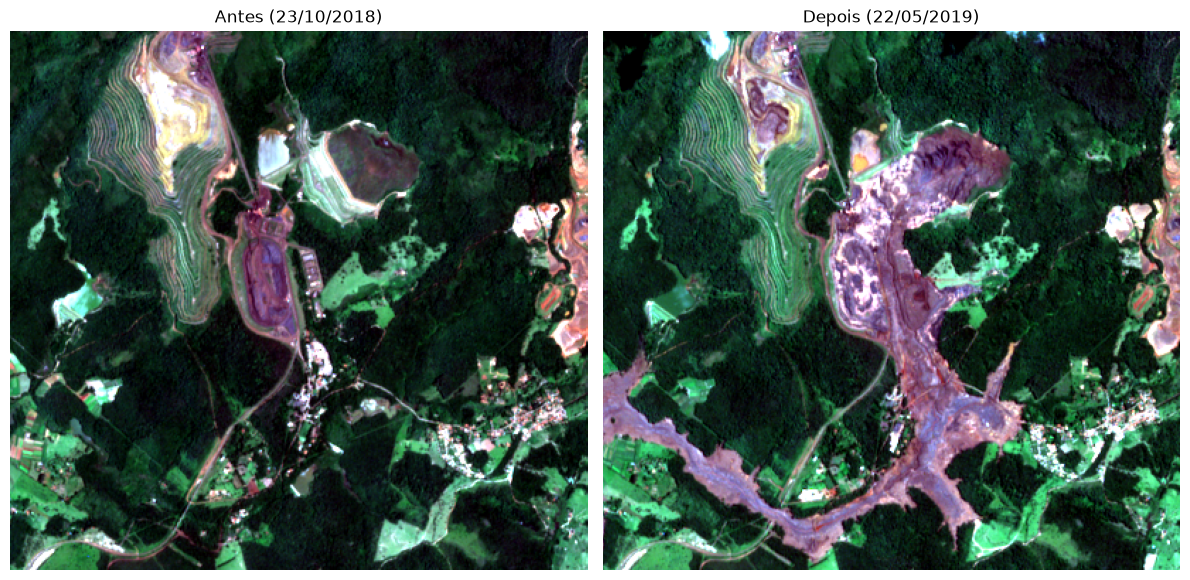

In [26]:
# aqui normalizando por percentil mas poderia ser normalizado por min/max
def normalize(array, lo_pct=2, hi_pct=98):
    """Normaliza um array numpy usando um contraste por percentil"""
    data = np.ma.filled(array, np.nan).astype("float64")
    valid = data[np.isfinite(data)]
    p_lo, p_hi = np.percentile(valid, [lo_pct, hi_pct])
    normalized = (array - p_lo) / (p_hi - p_lo)
    return np.clip(normalized, 0, 1)


# apenas empilha as imagens em um unico object numpy
def make_rgb(red, green, blue):
    return np.dstack((normalize(red), normalize(green), normalize(blue)))


rgb_antes = make_rgb(red_antes, green_antes, blue_antes)
rgb_depois = make_rgb(red_depois, green_depois, blue_depois)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(rgb_antes)
ax1.set_title("Antes (23/10/2018)")
ax1.axis("off")
ax2.imshow(rgb_depois)
ax2.set_title("Depois (22/05/2019)")
ax2.axis("off")
plt.tight_layout()
plt.show()

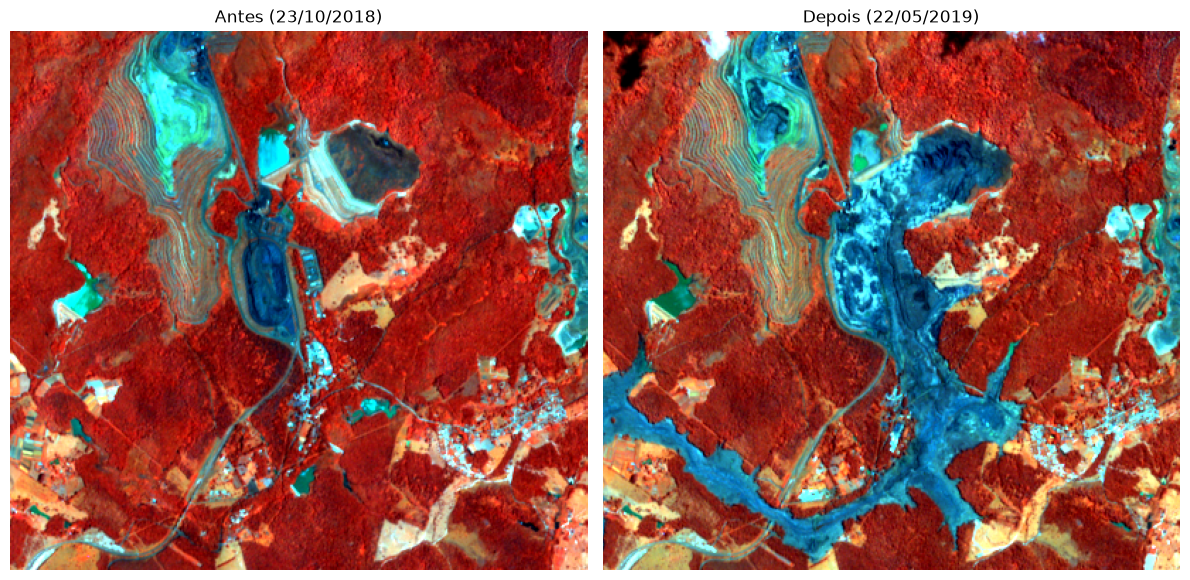

In [ ]:
### Criando uma composicao falsa cor
# aqui normalizando por percentil mas poderia ser normalizado por min/max

rgb_antes = make_rgb(nir_antes, green_antes, blue_antes)
rgb_depois = make_rgb(nir_depois, green_depois, blue_depois)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(rgb_antes)
ax1.set_title("Antes (23/10/2018)")
ax1.axis("off")
ax2.imshow(rgb_depois)
ax2.set_title("Depois (22/05/2019)")
ax2.axis("off")
plt.tight_layout()
plt.show()

## Índices espectrais

Agora vamos calcular três índices amplamente usados em sensoriamento remoto:

- **NDVI** (Normalized Difference Vegetation Index)
- **NDWI** (Normalized Difference Water Index): presença de água/umidade
- **EVI** (Enhanced Vegetation Index): parecido com o NDVI, mas corrige efeitos atmosféricos e de solo

Alem disso, vamos tentar utilizar um indice espectral para realçar a quantidade de material particulado presente na agua ou solo exposto, para isso, utilizando o catálogo de indices espectrais presente em: [Awesome Spectral Indices](https://awesome-spectral-indices.github.io/awesome-spectral-indices/)

Vamos prosseguir com os índices
- ****
- ****

In [46]:
def calc_ndvi(nir, red):
    """NDVI = (NIR - RED) / (NIR + RED)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return (nir - red) / (nir + red)


def calc_ndwi(green, nir):
    """NDWI (McFeeters) = (GREEN - NIR) / (GREEN + NIR)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return (green - nir) / (green + nir)


def calc_evi(nir, red, blue, G=2.5, C1=6, C2=7.5, L=1):
    """EVI = G * (NIR - RED) / (NIR + C1*RED - C2*BLUE + L)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return G * (nir - red) / (nir + C1 * red - C2 * blue + L)


def calc_soil_index(B, G, R, N, S1, S2):
    "Normalized Shortwave Infrared Difference Soil-Moisture"
    with np.errstate(divide="ignore",invalid="ignore"):
        return (S1 - S2)/(S1 + S2)

In [44]:
ndvi_antes = calc_ndvi(nir_antes, red_antes)
ndvi_depois = calc_ndvi(nir_depois, red_depois)

ndwi_antes = calc_ndwi(green_antes, nir_antes)
ndwi_depois = calc_ndwi(green_depois, nir_depois)

evi_antes = calc_evi(nir_antes, red_antes, blue_antes)
evi_depois = calc_evi(nir_depois, red_depois, blue_depois)

## soil index
## quando calculamos a banda SWIR1 temos um problema, já que sua resolução é 20 metros e a resolucao de R,G,B,N é 10 metros. 
## Portanto, ou resampleamos com numpy todas as bandas para 20 metros, ou pegamos direto do STAC as bandas já em 20 metros. 
## Irei pegar direto do STAC
## a banda de NIR vou resamplear na mao usando o scikit-image
import skimage as ski
nir_antes_20 = ski.transform.resize(nir_antes,(swir1_antes_20.shape))
nir_depois_20 = ski.transform.resize(nir_depois,(swir1_depois_20.shape))

soil_antes = calc_soil_index(blue_antes_20,green_antes_20,red_antes_20, nir_antes_20, swir1_antes_20, swir2_antes_20)
soil_depois = calc_soil_index(blue_depois_20, green_depois_20, red_depois_20, nir_depois_20, swir1_depois_20, swir2_depois_20)
check_memory("depois de calcular os índices")

[RAM] depois de calcular os índices: 14.65 GB usados de 32.00 GB (56.1%) | disponível: 14.04 GB


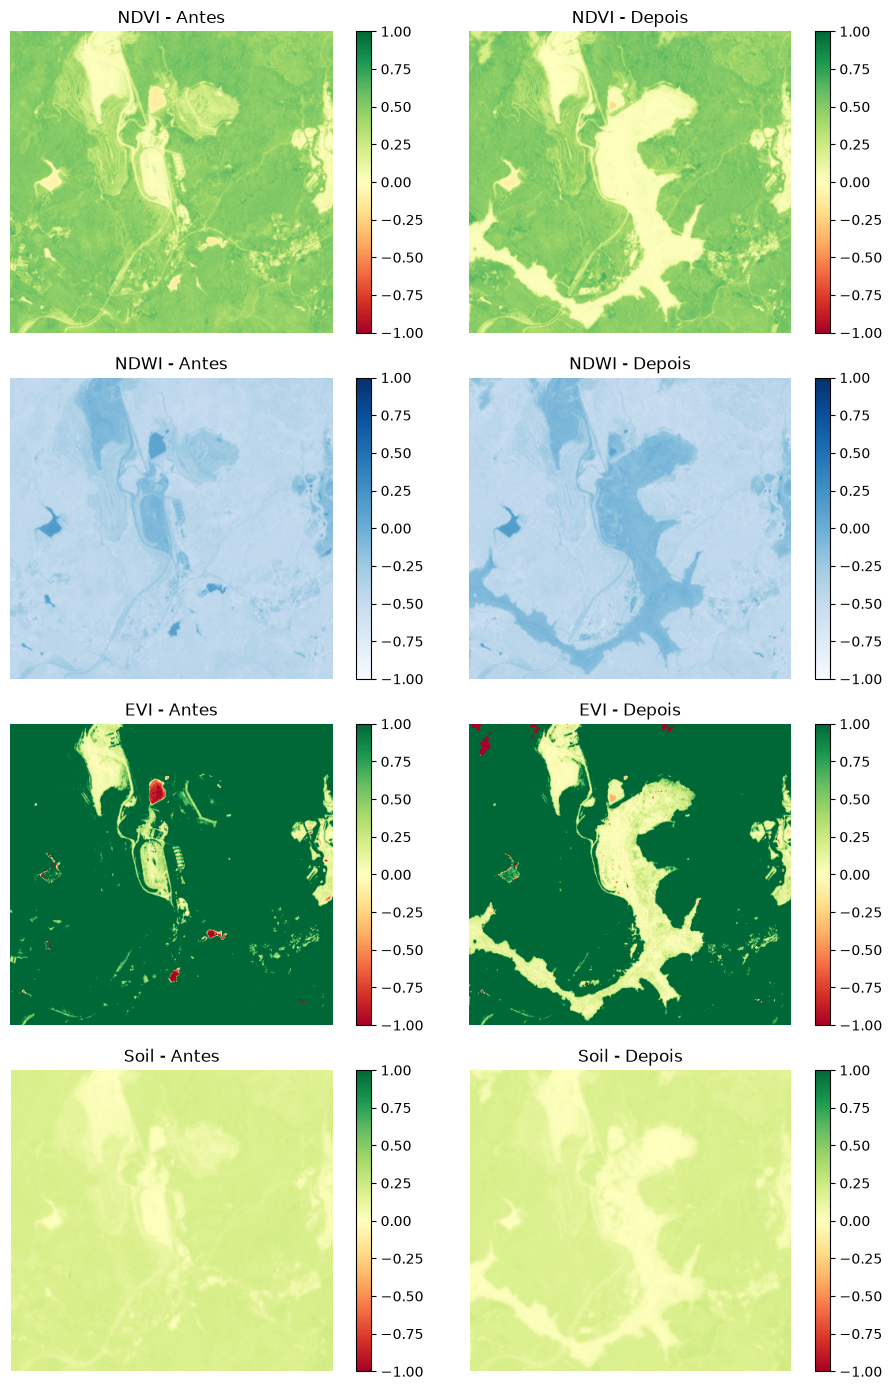

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for ax, data, title in zip(axes[0], [ndvi_antes, ndvi_depois], ["NDVI - Antes", "NDVI - Depois"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax, data, title in zip(axes[1], [ndwi_antes, ndwi_depois], ["NDWI - Antes", "NDWI - Depois"]):
    im = ax.imshow(data, cmap="Blues", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax, data, title in zip(axes[2], [evi_antes, evi_depois], ["EVI - Antes", "EVI - Depois"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)


for ax, data, title in zip(axes[3], [soil_antes, soil_depois], ["Soil - Antes", "Soil - Depois"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## Histograma

O histograma mostra como os valores do índice estão distribuídos na imagem. Vamos olhar o NDVI de antes do rompimento.

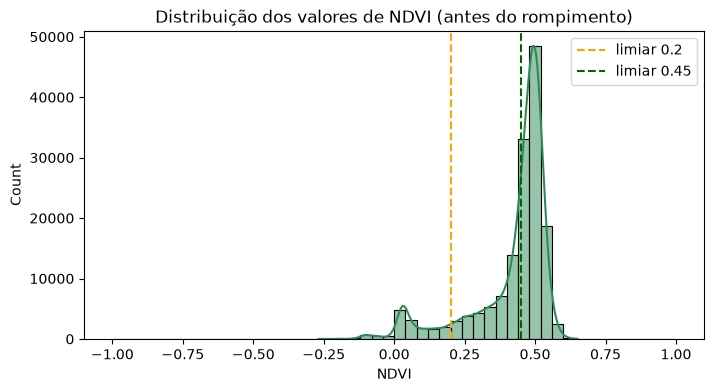

In [ ]:
ndvi_flat = np.ma.filled(ndvi_antes, np.nan).ravel()
ndvi_flat = ndvi_flat[np.isfinite(ndvi_flat)]

plt.figure(figsize=(8, 4))
sns.histplot(ndvi_flat, kde=True, 
             color="seagreen", 
             binrange=(-1, 1), 
             bins=50
             )
plt.axvline(0.2, color="orange", linestyle="--", label="limiar 0.2")
plt.axvline(0.45, color="darkgreen", linestyle="--", label="limiar 0.45")
plt.title("Distribuição dos valores de NDVI (antes do rompimento)")
plt.xlabel("NDVI")
plt.legend()
plt.show()

In [71]:
evi_normalized

array([0.87793689, 0.87822718, 0.87827761, ..., 0.87648972, 0.87642845,
       0.87650834], shape=(155447,))

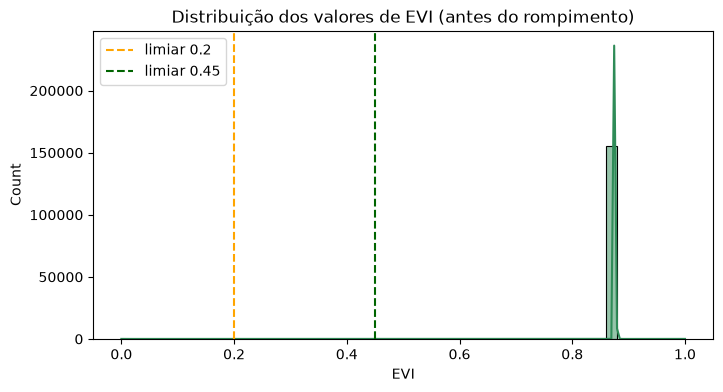

In [73]:
evi_flat = np.ma.filled(evi_antes, np.nan).ravel()
evi_flat = evi_flat[np.isfinite(evi_flat)]
evi_normalized = (evi_flat - evi_flat.min()) / (evi_flat.max() - evi_flat.min())
plt.figure(figsize=(8, 4))
sns.histplot(evi_normalized, 
             kde=True, 
             color="seagreen", 
             binrange=(0, 1), 
             bins=50)
plt.axvline(0.2, color="orange", linestyle="--", label="limiar 0.2")
plt.axvline(0.45, color="darkgreen", linestyle="--", label="limiar 0.45")
plt.title("Distribuição dos valores de EVI (antes do rompimento)")
plt.xlabel("EVI")
plt.legend()
plt.show()

## Classificação por limiar (thresholding)

Com base no histograma, podemos definir limiares para classificar a imagem em classes. Para o NDVI:

- `< 0.2`: solo exposto / água / área urbana
- `0.2 – 0.45`: vegetação esparsa/fraca
- `>= 0.45`: vegetação vigorosa

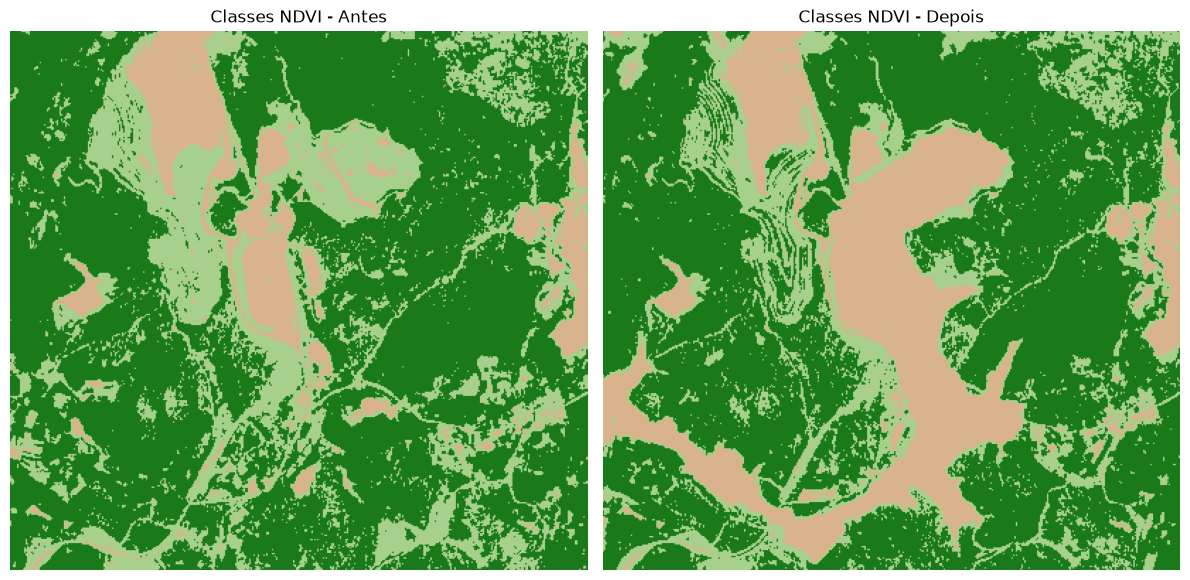

In [76]:
def classify_ndvi(ndvi):
    """0 = sem dado, 1 = solo/água/urbano, 2 = vegetação fraca, 3 = vegetação vigorosa"""
    ndvi_filled = np.ma.filled(ndvi, np.nan)
    classes = np.zeros_like(ndvi_filled, dtype=np.int8)
    classes[ndvi_filled < 0.2] = 1
    classes[(ndvi_filled >= 0.2) & (ndvi_filled < 0.45)] = 2
    classes[ndvi_filled >= 0.45] = 3
    return classes


classes_antes = classify_ndvi(ndvi_antes)
classes_depois = classify_ndvi(ndvi_depois)

cmap = ListedColormap(["black", "#d9b38c", "#a8d08d", "#1a7a1a"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(classes_antes, cmap=cmap, vmin=0, vmax=3)
ax1.set_title("Classes NDVI - Antes")
ax1.axis("off")
ax2.imshow(classes_depois, cmap=cmap, vmin=0, vmax=3)
ax2.set_title("Classes NDVI - Depois")
ax2.axis("off")
plt.tight_layout()
plt.show()

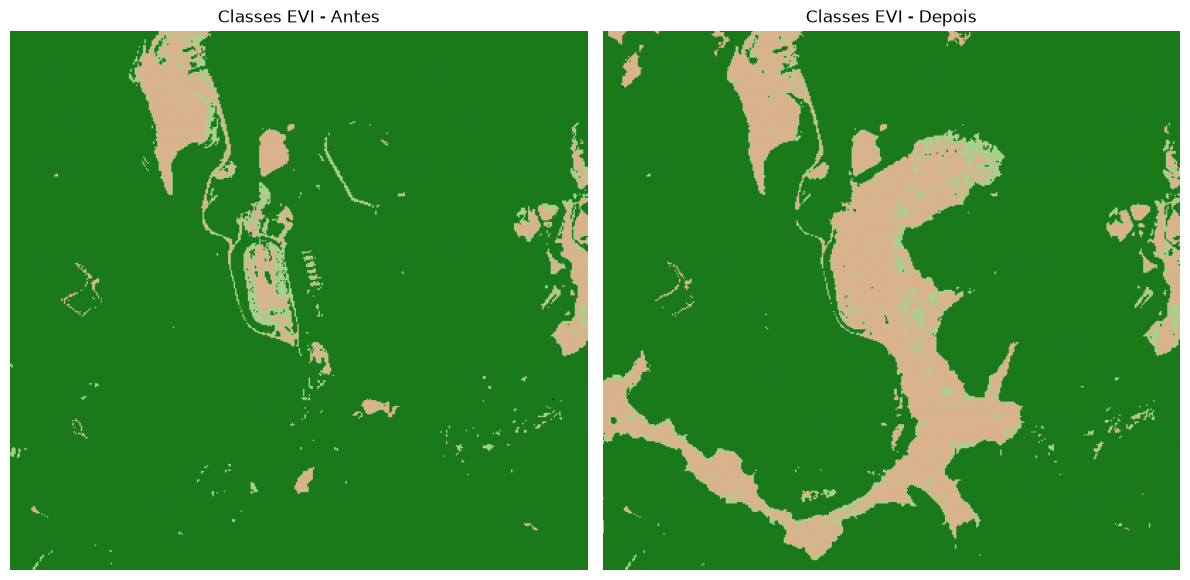

In [77]:
def classify_evi(evi):
    """0 = sem dado, 
    1 = solo/água/urbano,  
    2 = vegetação"""
    evi_filled = np.ma.filled(evi, np.nan)
    classes = np.zeros_like(evi_filled, dtype=np.int8)
    classes[evi_filled < 0.75] = 1
    classes[(evi_filled >= 0.75)] = 2
    return classes


classes_antes = classify_ndvi(evi_antes)
classes_depois = classify_ndvi(evi_depois)

cmap = ListedColormap(["black", "#d9b38c", "#a8d08d", "#1a7a1a"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(classes_antes, cmap=cmap, vmin=0, vmax=3)
ax1.set_title("Classes EVI - Antes")
ax1.axis("off")
ax2.imshow(classes_depois, cmap=cmap, vmin=0, vmax=3)
ax2.set_title("Classes EVI - Depois")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# FAÇA AQUI A CLASSIFICAO DO NDWI 

## Diferença entre as imagens (antes x depois)

Agora vamos para uma parte importante, vamos avaliar a diferença entre uma image e outra. Note que essa diferença é feita pixel-to-pixel, onde cada entrada de um pixel é analisada especificamente referente ao pixel da outra imagem na mesma posição. Isso requer que os rasteres estejam alinhandos, projetados no mesmo CRS e possuam o mesmo np.shape.

Subtraindo o NDVI de depois pelo de antes, conseguimos visualizar exatamente onde a vegetação foi destruída pela onda de rejeitos. Valores bem negativos (azul) indicam perda de vegetação/solo coberto pela lama.

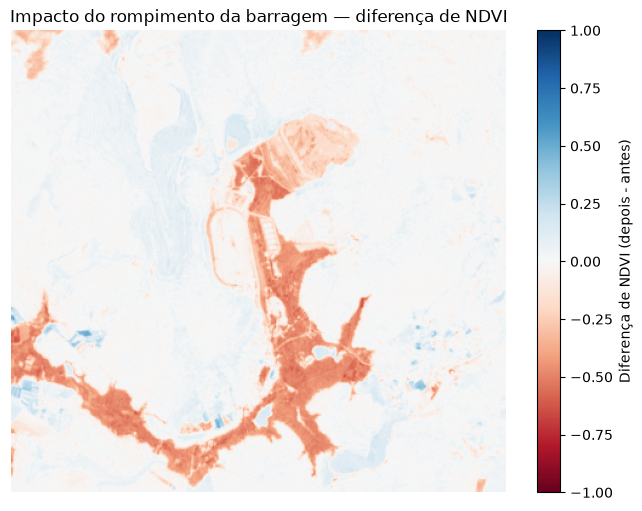

Diferença média de NDVI: -0.037199162
Pixels com forte perda de vegetação (diff < -0.3): 13679


In [78]:
ndvi_diff = np.ma.filled(ndvi_depois, np.nan) - np.ma.filled(ndvi_antes, np.nan)

plt.figure(figsize=(8, 6))
im = plt.imshow(ndvi_diff, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(im, label="Diferença de NDVI (depois - antes)")
plt.title("Impacto do rompimento da barragem — diferença de NDVI")
plt.axis("off")
plt.show()

print("Diferença média de NDVI:", np.nanmean(ndvi_diff))
print("Pixels com forte perda de vegetação (diff < -0.3):", np.sum(ndvi_diff < -0.3))

Se eu tenho 13.000 pixels que mudaram a vegetação, e portanto, eu sei o tamanho de cada pixel, isso significa que eu posso estimar a área afetada.

In [83]:
# Aqui eu considero que toda a mudança na image que foi maior que 0.3 foi portanto perda de vegetação em função do rompimento da barragem
total_pixels_alterados = np.sum(ndvi_diff < -0.3)

# sabendo que cada pixel tem a resolução de 10m
area_m2 = total_pixels_alterados*10*10
area_km2 = area_m2 / 1e6

print(f"Area afetada em m2: {area_m2}")
print(f"Area afetada em km2:{area_km2}")

Area afetada em m2: 1367900
Area afetada em km2:1.3679


## 8. E a água?

O rejeito de mineração se comporta de forma parecida com água/lama nas bandas espectrais. Vamos ver a diferença de NDWI também, que pode evidenciar a lama e o assoreamento do Rio Paraopeba.

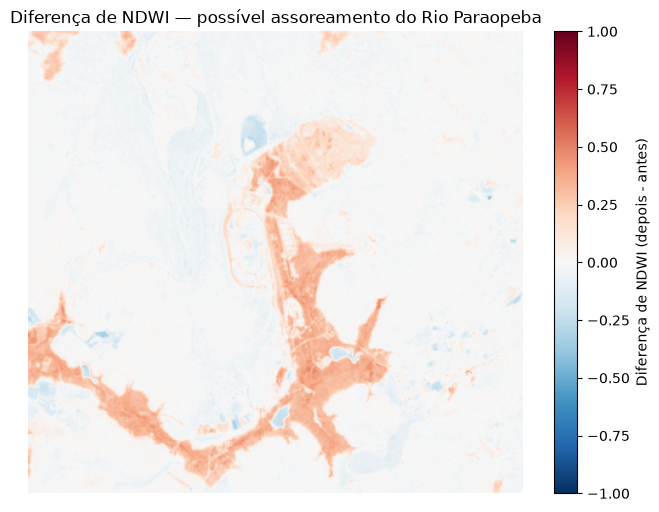

[RAM] fim do notebook: 15.29 GB usados de 32.00 GB (58.1%) | disponível: 13.41 GB


In [ ]:
ndwi_diff = np.ma.filled(ndwi_depois, np.nan) - np.ma.filled(ndwi_antes, np.nan)

plt.figure(figsize=(8, 6))
im = plt.imshow(ndwi_diff, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Diferença de NDWI (depois - antes)")
plt.title("Diferença de NDWI — possível assoreamento do Rio Paraopeba")
plt.axis("off")
plt.show()



# Referências

- [Brazil Data Cube - stac-image-processing.ipynb](https://github.com/brazil-data-cube/code-gallery/blob/master/jupyter/Python/stac/stac-image-processing.ipynb)
- Catálogo STAC: [https://data.inpe.br/bdc/stac/v1/](https://data.inpe.br/bdc/stac/v1/)